In [3]:
import pandas as pd
import os
from pathlib import Path
import duckdb
from collections import defaultdict
import string
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

In [4]:
usage_db = duckdb.connect("usage_db.duckdb")

In [5]:
hour_counts = usage_db.execute("""
    SELECT
        hour(start_date) AS hour,
        COUNT(*)         AS trip_count
    FROM trips
    GROUP BY hour
    ORDER BY hour
""").fetchdf()

In [6]:
hour_counts["proportion"] = (hour_counts["trip_count"] / hour_counts["trip_count"].sum())

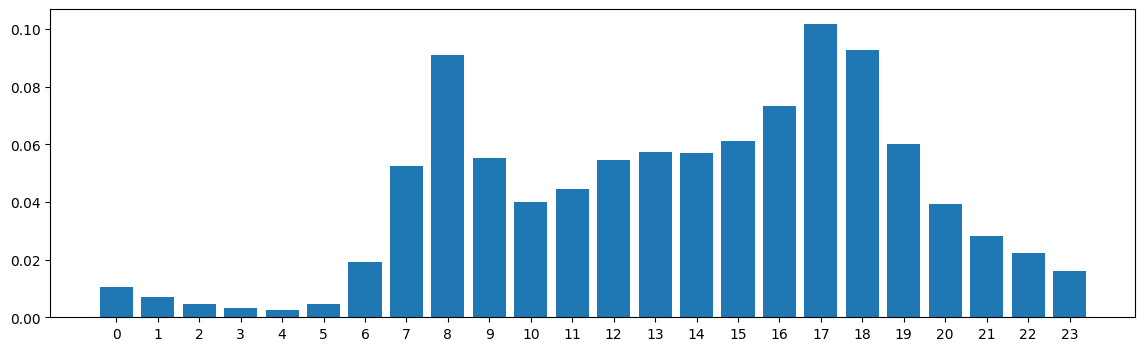

In [7]:
plt.figure(figsize=(14, 4))  
plt.bar(x = hour_counts["hour"], height = hour_counts["proportion"])
plt.xticks(hour_counts["hour"]) 
plt.show()

In [14]:
hour_counts_day = usage_db.execute("""
    SELECT
        dayname(start_date) as day,
        hour(start_date) AS hour,
        COUNT(*)         AS trip_count
    FROM trips
    GROUP BY hour, day
    ORDER BY hour
""").fetchdf()

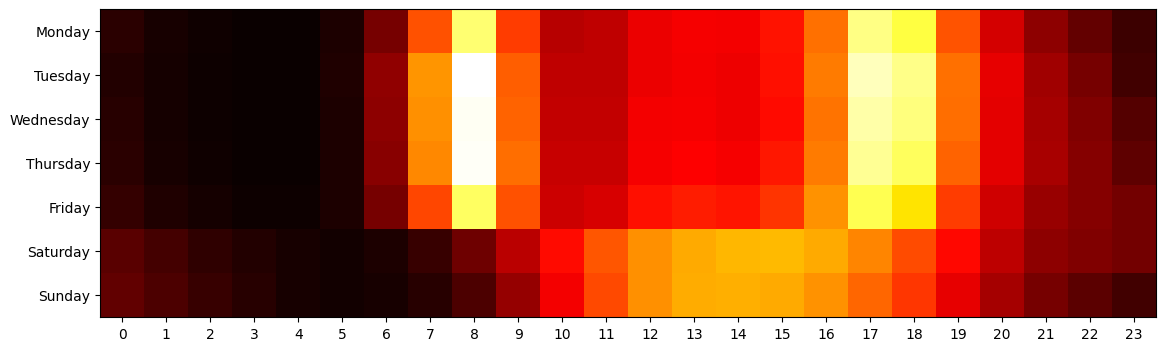

In [10]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hour_counts_day["day"] = pd.Categorical(hour_counts_day["day"], categories=day_order, ordered=True)
hour_counts_day = hour_counts_day.sort_values("day")

hour_counts_day_pivot = hour_counts_day.pivot(index="day", columns="hour", values="trip_count")

plt.figure(figsize=(14, 4))  
plt.imshow(hour_counts_day_pivot, cmap="hot")
plt.xticks(range(len(hour_counts_day_pivot.columns)), hour_counts_day_pivot.columns)
plt.yticks(range(len(day_order)), day_order)
plt.show()  

In [25]:
seasonal_trends = usage_db.execute("""
    SELECT
        date(start_date) as date,
        COUNT(*) AS trip_count
    FROM trips
    GROUP BY date
    ORDER BY date
""").fetch_df()

In [32]:
seasonal_trends

,date,trip_count
0,2012-01-04,13936
1,2012-01-05,14191
2,2012-01-06,17713
3,2012-01-07,12556
4,2012-01-08,10487
...,...,...
3730,2024-09-26,24899
3731,2024-09-27,19499
3732,2024-09-28,25514
3733,2024-09-29,18982


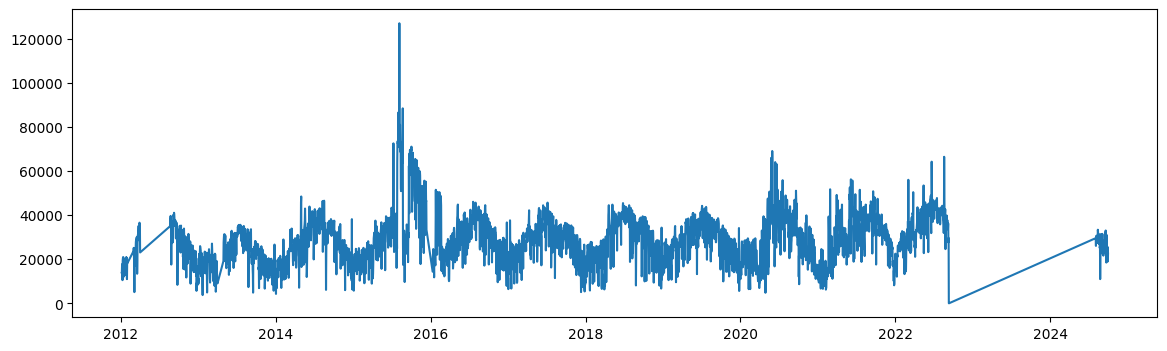

In [31]:
plt.figure(figsize=(14, 4))  

plt.plot(seasonal_trends["date"],seasonal_trends["trip_count"])

In [33]:
usage_db.close()